<a href="https://colab.research.google.com/github/ElPunch/pneumonia-classification-deep-learning/blob/main/Proyecto_ia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


Redireccionamiento de imagenes

In [ ]:
import os
from PIL import Image

# Define the input and output directories
# The actual image data is typically nested one level deeper in this dataset structure
input_data_root = os.path.join(path, 'chest_xray')
output_base_dir = './resized_chest_xray_balanced_limited'

# Define the target size
target_size = (244, 244)

# Limit the total number of images to process
MAX_TOTAL_IMAGES = 6000
# To ensure some balance, we can set a limit per sub-category (train/normal, train/pneumonia, etc.)
# There are 6 such primary categories under chest_xray (train, test, val each with NORMAL, PNEUMONIA)
MAX_PER_CATEGORY = MAX_TOTAL_IMAGES // 6
if MAX_TOTAL_IMAGES % 6 != 0:
    MAX_PER_CATEGORY += 1 # Distribute remainder to ensure total is met or slightly exceeded if needed

# Dictionary to keep track of processed images per category (e.g., 'train/NORMAL')
processed_counts = {}
total_processed_images = 0

print(f"Resizing up to {MAX_TOTAL_IMAGES} images (approx. {MAX_PER_CATEGORY} per category) to {target_size} and saving to '{output_base_dir}'...")

# Walk through the input directory structure
for root, dirs, files in os.walk(input_data_root):
    # Filter out __MACOSX directories from the list to be traversed by os.walk
    # This prevents the walk from entering these problematic directories
    dirs[:] = [d for d in dirs if d != '__MACOSX']

    # Determine the category for the current root (e.g., 'train/NORMAL')
    # relative_path from input_data_root gives 'train/NORMAL', 'train/PNEUMONIA', etc.
    relative_path = os.path.relpath(root, input_data_root)

    # Skip processing if we are at an intermediate directory level (like 'train', 'test', 'val')
    # or the root itself, as images are expected in sub-sub-directories
    if relative_path == '.' or len(relative_path.split(os.sep)) < 2:
        continue

    current_category = relative_path # e.g., 'train/NORMAL'
    if current_category not in processed_counts:
        processed_counts[current_category] = 0

    for file in files:
        if total_processed_images >= MAX_TOTAL_IMAGES:
            print(f"Reached maximum of {MAX_TOTAL_IMAGES} total images. Stopping.")
            break # Exit the inner loop (files)

        if processed_counts[current_category] >= MAX_PER_CATEGORY:
            # print(f"Reached maximum for category '{current_category}'. Skipping remaining files in this category.") # Optional: for debugging
            break # Exit the inner loop for this category, move to next root

        # Skip any metadata files like .DS_Store or files explicitly within __MACOSX paths
        if file.startswith('.') or '__MACOSX' in root:
            continue

        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            input_filepath = os.path.join(root, file)

            output_dir = os.path.join(output_base_dir, relative_path)
            os.makedirs(output_dir, exist_ok=True)
            output_filepath = os.path.join(output_dir, file)

            try:
                with Image.open(input_filepath) as img:
                    img_resized = img.resize(target_size, Image.Resampling.LANCZOS)
                    # Ensure correct format for saving based on file extension
                    if output_filepath.lower().endswith(('.jpeg', '.jpg')):
                        img_resized.save(output_filepath, format='JPEG')
                    elif output_filepath.lower().endswith('.png'):
                        img_resized.save(output_filepath, format='PNG')
                    else:
                        # Default to PNG if file type is ambiguous or other format
                        img_resized.save(output_filepath)

                    processed_counts[current_category] += 1
                    total_processed_images += 1
            except Exception as e:
                print(f"Error processing {input_filepath}: {e}")
    else:
        continue # Continue to the next root directory if inner loop completed normally
    break # Break the outer loop (root) if total_processed_images limit was reached

print(f"Image resizing complete! Total images processed: {total_processed_images}")
print("Processed counts per category:")
for category, count in processed_counts.items():
    print(f"- {category}: {count}")

Resizing up to 6000 images (approx. 1000 per category) to (244, 244) and saving to './resized_chest_xray_balanced_limited'...
Image resizing complete! Total images processed: 1640
Processed counts per category:
- chest_xray/val: 0
- chest_xray/val/PNEUMONIA: 8
- chest_xray/val/NORMAL: 8
- chest_xray/test: 0
- chest_xray/test/PNEUMONIA: 390
- chest_xray/test/NORMAL: 234
- chest_xray/train: 0
- chest_xray/train/PNEUMONIA: 1000


Limpieza de los datos

In [ ]:
import os
from PIL import Image
import pandas as pd

# The directory where the resized images are stored
output_base_dir = './resized_chest_xray_balanced_limited'

# Dictionary to store counts
image_counts = {
    'train': {'NORMAL': 0, 'PNEUMONIA': 0},
    'test': {'NORMAL': 0, 'PNEUMONIA': 0},
    'val': {'NORMAL': 0, 'PNEUMONIA': 0}
}

corrupted_images = []

print(f"Starting data cleaning and counting from: {output_base_dir}")

# Walk through the output directory structure
for root, dirs, files in os.walk(output_base_dir):
    # Extract the split (train, test, val) and class (NORMAL, PNEUMONIA)
    # The structure is expected to be e.g., './resized_chest_xray_balanced_limited/chest_xray/train/NORMAL'
    path_parts = root.split(os.sep)

    # Check if the path corresponds to a class directory (e.g., .../train/NORMAL or .../test/PNEUMONIA)
    if len(path_parts) >= 4 and path_parts[-2] in ['train', 'test', 'val'] and path_parts[-1] in ['NORMAL', 'PNEUMONIA']:
        split = path_parts[-2]
        img_class = path_parts[-1]

        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                filepath = os.path.join(root, file)
                try:
                    with Image.open(filepath) as img:
                        img.verify() # Verify that it is an image
                        image_counts[split][img_class] += 1
                except Exception as e:
                    corrupted_images.append(filepath)
                    # print(f"Warning: Corrupted or unreadable image found and skipped: {filepath} ({e})")

print("\n--- Image Counts by Split and Class ---")
data_for_df = []
for split, classes in image_counts.items():
    for img_class, count in classes.items():
        data_for_df.append({'Split': split, 'Class': img_class, 'Count': count})

df_counts = pd.DataFrame(data_for_df)
print(df_counts.to_string(index=False))

print(f"\nTotal images processed: {df_counts['Count'].sum()}")

if corrupted_images:
    print(f"\n--- Detected Corrupted/Unreadable Images ({len(corrupted_images)} found) ---")
    for img_path in corrupted_images[:10]: # Print up to 10 corrupted paths
        print(img_path)
    if len(corrupted_images) > 10:
        print(f"... and {len(corrupted_images) - 10} more.")
else:
    print("\nNo corrupted or unreadable images detected in the processed dataset.")


Starting data cleaning and counting from: ./resized_chest_xray_balanced_limited

--- Image Counts by Split and Class ---
Split     Class  Count
train    NORMAL      0
train PNEUMONIA   1000
 test    NORMAL    234
 test PNEUMONIA    390
  val    NORMAL      8
  val PNEUMONIA      8

Total images processed: 1640

No corrupted or unreadable images detected in the processed dataset.


Analisis y visualizacion de los datos


--- Overall Class Distribution ---
    Class  Count
   NORMAL    242
PNEUMONIA   1398

--- Overall Class Distribution (Percentage) ---
    Class  Percentage
   NORMAL   14.756098
PNEUMONIA   85.243902


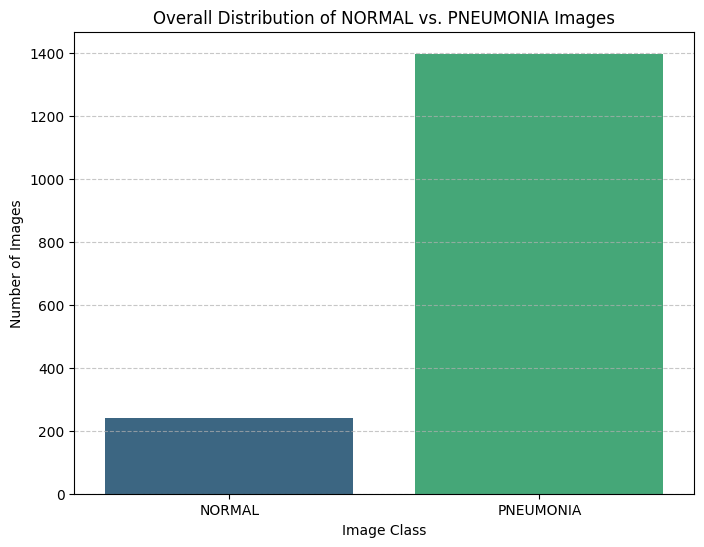

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate counts by class across all splits
overall_class_counts = df_counts.groupby('Class')['Count'].sum().reset_index()

print("\n--- Overall Class Distribution ---")
print(overall_class_counts.to_string(index=False))

# Calculate percentages
total_images = overall_class_counts['Count'].sum()
overall_class_counts['Percentage'] = (overall_class_counts['Count'] / total_images) * 100
print("\n--- Overall Class Distribution (Percentage) ---")
print(overall_class_counts[['Class', 'Percentage']].to_string(index=False))

# Visualize the overall class distribution
fig = plt.figure(figsize=(8, 6))
sns.barplot(x='Class', y='Count', data=overall_class_counts, palette='viridis', hue='Class', legend=False)
plt.title('Overall Distribution of NORMAL vs. PNEUMONIA Images')
plt.xlabel('Image Class')
plt.ylabel('Number of Images')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
